# Exploratory Data Analysis — PaySim Transaction Log

**Dataset:** `producer/sample_dataset/PS_20174392719_1491204439457_log.csv`  
**Source:** [PaySim](https://www.kaggle.com/datasets/ealaxi/paysim1) — synthetic mobile-money transactions derived from real financial logs.

**Goal:** Understand structure, quality, and fraud signals so we can define transformations that feed the real-time pipeline (`TransactionEvent` in `shared/schema.py`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "analysis":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "producer" / "sample_dataset" / "PS_20174392719_1491204439457_log.csv"
assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"

## 1. Load data

~6.36M rows (~471 MB). Use explicit dtypes to reduce memory. Full load is feasible on a typical dev machine (~2–3 GB RAM).

In [2]:
DTYPES = {
    "step": "int32",
    "type": "category",
    "amount": "float64",
    "nameOrig": "string",
    "oldbalanceOrg": "float64",
    "newbalanceOrig": "float64",
    "nameDest": "string",
    "oldbalanceDest": "float64",
    "newbalanceDest": "float64",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(DATA_PATH, dtype=DTYPES)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
df.head()

Shape: 6,362,620 rows × 11 columns
Memory: 1.06 GB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


## 2. Schema & data types

In [3]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float64 
 3   nameOrig        string  
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        string  
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float64(5), int32(1), int8(2), string(2)
memory usage: 382.3 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,"6,362,620.00",NaN,NaN,NaN,243.40,142.33,1.00,156.00,239.00,335.00,743.00
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,"6,362,620.00",NaN,NaN,NaN,"179,861.90","603,858.23",0.00,"13,389.57","74,871.94","208,721.48","92,445,516.64"
nameOrig,6362620,6353307,C2098525306,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,"6,362,620.00",NaN,NaN,NaN,"833,883.10","2,888,242.67",0.00,0.00,"14,208.00","107,315.18","59,585,040.37"
newbalanceOrig,"6,362,620.00",NaN,NaN,NaN,"855,113.67","2,924,048.50",0.00,0.00,0.00,"144,258.41","49,585,040.37"
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,"6,362,620.00",NaN,NaN,NaN,"1,100,701.67","3,399,180.11",0.00,0.00,"132,705.66","943,036.71","356,015,889.35"
newbalanceDest,"6,362,620.00",NaN,NaN,NaN,"1,224,996.40","3,674,128.94",0.00,0.00,"214,661.44","1,111,909.25","356,179,278.92"
isFraud,"6,362,620.00",NaN,NaN,NaN,0.00,0.04,0.00,0.00,0.00,0.00,1.00


In [4]:
missing = df.isna().sum()
dup_rows = df.duplicated().sum()
print("Missing values per column:")
display(missing[missing > 0] if missing.any() else pd.Series({"(none)": 0}))
print(f"Fully duplicate rows: {dup_rows:,}")
print(f"amount <= 0: {(df['amount'] <= 0).sum():,}")

Missing values per column:


(none)    0
dtype: int64

Fully duplicate rows: 0
amount <= 0: 16


## 3. Transaction types & class balance

,count,pct
type,,
CASH_OUT,2237500,35.17
PAYMENT,2151495,33.81
CASH_IN,1399284,21.99
TRANSFER,532909,8.38
DEBIT,41432,0.65


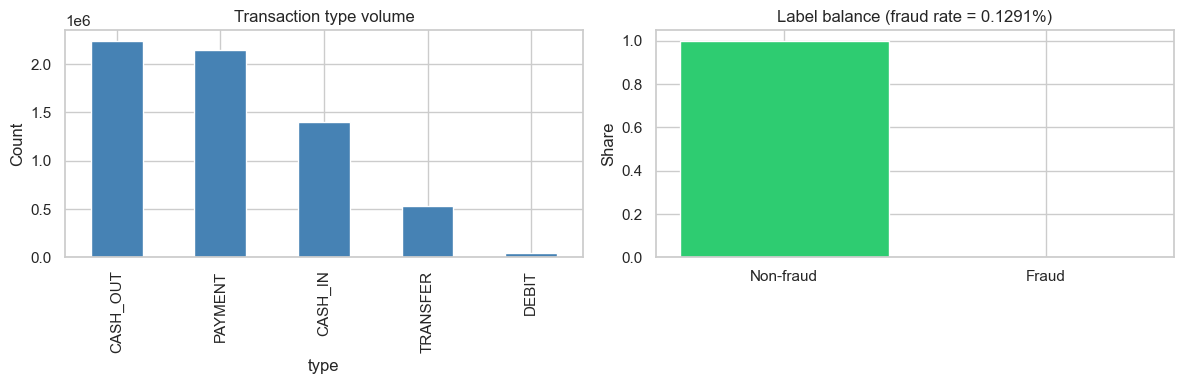

In [5]:
type_counts = df["type"].value_counts()
display(type_counts.to_frame("count").assign(pct=lambda x: 100 * x["count"] / len(df)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
type_counts.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Transaction type volume")
axes[0].set_ylabel("Count")

fraud_rate = df["isFraud"].mean()
axes[1].bar(["Non-fraud", "Fraud"], [1 - fraud_rate, fraud_rate], color=["#2ecc71", "#e74c3c"])
axes[1].set_title(f"Label balance (fraud rate = {fraud_rate:.4%})")
axes[1].set_ylabel("Share")
plt.tight_layout()
plt.show()

In [6]:
fraud_by_type = (
    df.groupby("type", observed=True)["isFraud"]
    .agg(count="count", frauds="sum", rate="mean")
    .sort_values("rate", ascending=False)
)
display(fraud_by_type)
print(
    "Fraud only appears in TRANSFER and CASH_OUT — aligns with PaySim fraud simulation "
    "(drain account via transfer/cash-out)."
)

,count,frauds,rate
type,,,
TRANSFER,532909,4097,0.01
CASH_OUT,2237500,4116,0.00
CASH_IN,1399284,0,0.00
DEBIT,41432,0,0.00
PAYMENT,2151495,0,0.00


Fraud only appears in TRANSFER and CASH_OUT — aligns with PaySim fraud simulation (drain account via transfer/cash-out).


## 4. Amount distribution

In [7]:
amount_stats = df["amount"].describe(percentiles=[0.5, 0.95, 0.99]).to_frame("all")
amount_stats["fraud"] = df.loc[df["isFraud"] == 1, "amount"].describe(percentiles=[0.5, 0.95, 0.99])
amount_stats["non_fraud"] = df.loc[df["isFraud"] == 0, "amount"].describe(percentiles=[0.5, 0.95, 0.99])
display(amount_stats.T)

for label, subset in [("All", df), ("Fraud", df[df["isFraud"] == 1]), ("Non-fraud", df[df["isFraud"] == 0])]:
    p50, p95, p99 = subset["amount"].quantile([0.5, 0.95, 0.99])
    print(f"{label:10} P50={p50:,.0f}  P95={p95:,.0f}  P99={p99:,.0f}")

,count,mean,std,min,50%,95%,99%,max
all,"6,362,620.00","179,861.90","603,858.23",0.00,"74,871.94","518,634.20","1,615,979.47","92,445,516.64"
fraud,"8,213.00","1,467,967.30","2,404,252.95",0.00,"441,423.44","8,006,429.04","10,000,000.00","10,000,000.00"
non_fraud,"6,354,407.00","178,197.04","596,236.98",0.01,"74,684.72","515,610.42","1,586,064.17","92,445,516.64"


All        P50=74,872  P95=518,634  P99=1,615,979
Fraud      P50=441,423  P95=8,006,429  P99=10,000,000
Non-fraud  P50=74,685  P95=515,610  P99=1,586,064


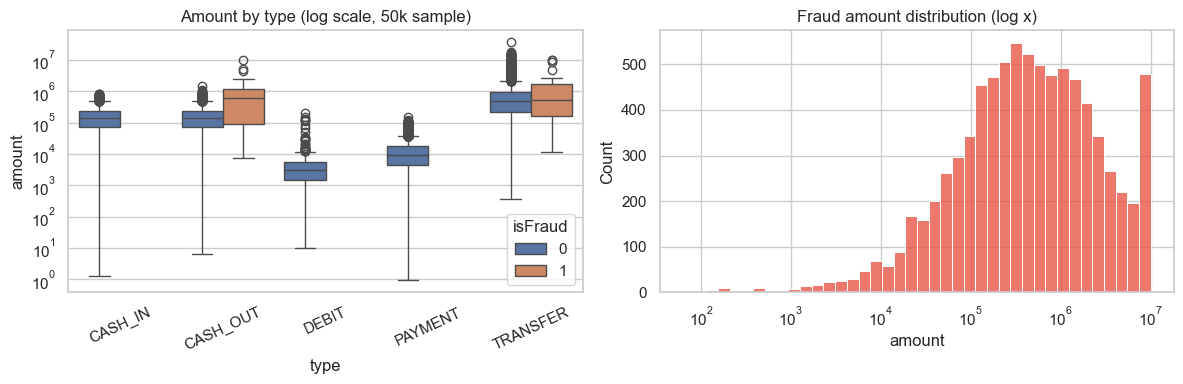

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = df.sample(n=min(50_000, len(df)), random_state=42)
sns.boxplot(data=sample, x="type", y="amount", hue="isFraud", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Amount by type (log scale, 50k sample)")
axes[0].tick_params(axis="x", rotation=25)

sns.histplot(
    data=df[df["isFraud"] == 1].sample(n=min(10_000, df["isFraud"].sum()), random_state=42),
    x="amount",
    log_scale=True,
    bins=40,
    ax=axes[1],
    color="#e74c3c",
)
axes[1].set_title("Fraud amount distribution (log x)")
plt.tight_layout()
plt.show()

## 5. Balance columns (PaySim-specific features)

Balances before/after for origin and destination accounts. Useful as **derived features** (e.g. balance delta, zero-balance flags) even though they are not in `TransactionEvent` today.

In [9]:
balance_cols = ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
display(df[balance_cols].describe().T)

zero_bal_pct = (
    df.groupby("type", observed=True)
    .agg(
        oldbalanceOrg_zero_pct=("oldbalanceOrg", lambda s: 100 * (s == 0).mean()),
        oldbalanceDest_zero_pct=("oldbalanceDest", lambda s: 100 * (s == 0).mean()),
    )
    .round(2)
)
display(zero_bal_pct)

,count,mean,std,min,25%,50%,75%,max
oldbalanceOrg,"6,362,620.00","833,883.10","2,888,242.67",0.00,0.00,"14,208.00","107,315.18","59,585,040.37"
newbalanceOrig,"6,362,620.00","855,113.67","2,924,048.50",0.00,0.00,0.00,"144,258.41","49,585,040.37"
oldbalanceDest,"6,362,620.00","1,100,701.67","3,399,180.11",0.00,0.00,"132,705.66","943,036.71","356,015,889.35"
newbalanceDest,"6,362,620.00","1,224,996.40","3,674,128.94",0.00,0.00,"214,661.44","1,111,909.25","356,179,278.92"


,oldbalanceOrg_zero_pct,oldbalanceDest_zero_pct
type,,
CASH_IN,0.96,11.69
CASH_OUT,45.85,14.49
DEBIT,14.86,0.00
PAYMENT,35.99,100.00
TRANSFER,53.06,12.22


In [10]:
# Accounting consistency: origin balance after debit-like flows
debit_like = df["type"].isin(["TRANSFER", "CASH_OUT", "DEBIT"])
expected_new = df["oldbalanceOrg"] - df["amount"]
mismatch = debit_like & (df["newbalanceOrig"] - expected_new).abs().gt(0.01)
print(f"Origin balance mismatch (transfer/cash_out/debit): {mismatch.sum():,} rows ({100 * mismatch.mean():.4f}%)")

Origin balance mismatch (transfer/cash_out/debit): 2,512,513 rows (39.4887%)


## 6. Temporal structure (`step`)

`step` is a **simulated hour index** (1 … 743), not a wall-clock timestamp. For the pipeline we must synthesize `timestamp` from a base datetime + `step`.

step range: 1 – 743 (743 unique hours)


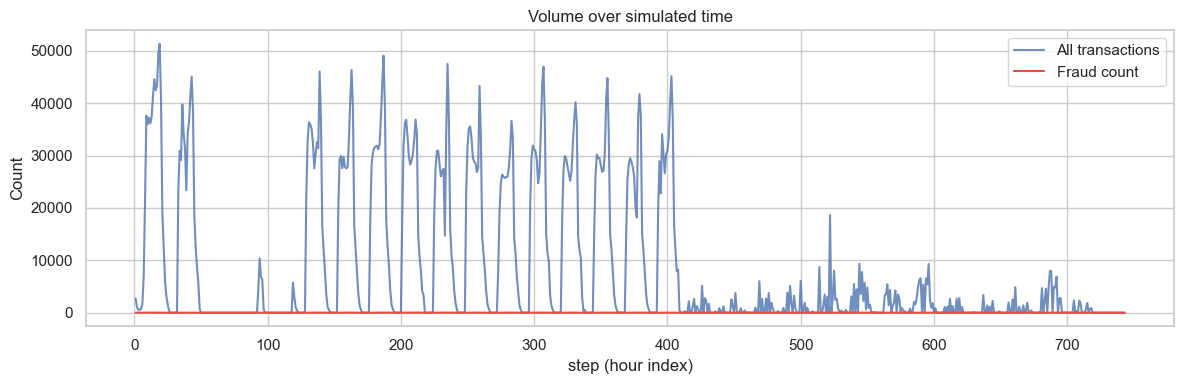

In [11]:
print(f"step range: {df['step'].min()} – {df['step'].max()} ({df['step'].nunique()} unique hours)")

tx_per_step = df.groupby("step").size()
fraud_per_step = df.groupby("step")["isFraud"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tx_per_step.index, tx_per_step.values, label="All transactions", alpha=0.8)
ax.plot(fraud_per_step.index, fraud_per_step.values, label="Fraud count", color="#e74c3c")
ax.set_xlabel("step (hour index)")
ax.set_ylabel("Count")
ax.set_title("Volume over simulated time")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Entities: customers vs merchants

- `nameOrig` is always a **customer** account (`C…`).
- `nameDest` is `C…` (peer customer) or `M…` (merchant) depending on `type`.

In [12]:
df["orig_prefix"] = df["nameOrig"].str[0]
df["dest_prefix"] = df["nameDest"].str[0]

print("Origin prefix:", df["orig_prefix"].value_counts().to_dict())
print("Dest prefix:", df["dest_prefix"].value_counts().to_dict())
print(f"Unique origin accounts: {df['nameOrig'].nunique():,}")
print(f"Unique dest (C): {df.loc[df['nameDest'].str.startswith('C'), 'nameDest'].nunique():,}")
print(f"Unique dest (M): {df.loc[df['nameDest'].str.startswith('M'), 'nameDest'].nunique():,}")

dest_by_type = pd.crosstab(df["type"], df["dest_prefix"], normalize="index")
display((dest_by_type * 100).round(2))

Origin prefix: {'C': 6362620}
Dest prefix: {'C': 4211125, 'M': 2151495}
Unique origin accounts: 6,353,307
Unique dest (C): 571,961
Unique dest (M): 2,150,401


dest_prefix,C,M
type,,
CASH_IN,100.00,0.00
CASH_OUT,100.00,0.00
DEBIT,100.00,0.00
PAYMENT,0.00,100.00
TRANSFER,100.00,0.00


## 8. Velocity (proxy for `VELOCITY_1H` rule)

Pipeline rule: >5 transactions per user per rolling hour. Here, `step` already buckets by hour, so we count transactions per `(nameOrig, step)`.

In [13]:
tx_per_user_step = df.groupby(["nameOrig", "step"]).size()
print(tx_per_user_step.describe())
print(f"Max tx per user per step: {tx_per_user_step.max()}")
print(f"Buckets with >5 tx: {(tx_per_user_step > 5).sum()}")
print(
    "PaySim has at most 2 tx/user/hour — velocity rule will NOT fire on raw replay; "
    "synthetic replay or time compression needed to stress-test VELOCITY_1H."
)

count   6,362,573.00
mean            1.00
std             0.00
min             1.00
25%             1.00
50%             1.00
75%             1.00
max             2.00
dtype: float64
Max tx per user per step: 2
Buckets with >5 tx: 0
PaySim has at most 2 tx/user/hour — velocity rule will NOT fire on raw replay; synthetic replay or time compression needed to stress-test VELOCITY_1H.


## 9. `isFlaggedFraud` vs `isFraud`

PaySim’s `isFlaggedFraud` reflects what a **simple bank rule** would catch (only large TRANSFER). Almost all fraud is unflagged — useful as a baseline for rule tuning.

In [14]:
flagged = df["isFlaggedFraud"].sum()
overlap = ((df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)).sum()
print(f"isFlaggedFraud=1: {flagged} rows")
print(f"Fraud AND flagged: {overlap}")
print(f"Fraud recall of naive flag rule: {overlap / df['isFraud'].sum():.2%}")

isFlaggedFraud=1: 16 rows
Fraud AND flagged: 16
Fraud recall of naive flag rule: 0.19%


## 10. Pipeline schema gap analysis

Target event model (`shared/schema.py` — `TransactionEvent`):

| Pipeline field | PaySim column | Notes |
|------------------|---------------|-------|
| `transaction_id` | — | Generate UUID per row |
| `user_id` | `nameOrig` | Customer account id |
| `timestamp` | `step` | Map `step` → `base_time + step hours` |
| `amount` | `amount` | Drop or clamp rows with `amount <= 0` (16 rows) |
| `currency` | — | Constant `"USD"` |
| `merchant_id` | `nameDest` | Use dest; for C2C use dest customer id |
| `merchant_category` | — | **Derive** from `type` (see mapping below) |
| `country` | — | **Synthetic** ISO-2 (not in PaySim) |
| `ip_country` | — | **Synthetic**; set equal to `country` or inject mismatch for GEO tests |
| `payment_method` | `type` | Map PAYMENT→card, TRANSFER/CASH_*→bank_transfer, DEBIT→card |
| `device_id` | — | Optional `null` |
| Labels | `isFraud` | Offline evaluation only — **do not** publish to Kafka |

**Rules engine** (`consumer/rules.py`) needs: amount percentiles, velocity, geo mismatch, new merchant — several require **fields we must invent** for PaySim replay.

In [15]:
TYPE_TO_PAYMENT = {
    "PAYMENT": "card",
    "DEBIT": "card",
    "TRANSFER": "bank_transfer",
    "CASH_IN": "bank_transfer",
    "CASH_OUT": "bank_transfer",
}
TYPE_TO_MCC = {
    "PAYMENT": "5999",   # general retail
    "DEBIT": "6011",     # ATM / cash
    "TRANSFER": "6012",  # financial institution
    "CASH_IN": "6011",
    "CASH_OUT": "6011",
}

p95 = df["amount"].quantile(0.95)
p99 = df["amount"].quantile(0.99)
print("Recommended global thresholds from this dataset:")
print(f"  global_amount_p95: {p95:,.2f}")
print(f"  global_amount_p99: {p99:,.2f}")
print(f"  baseline fraud rate: {df['isFraud'].mean():.4%}")
print("\nProposed type → payment_method:", TYPE_TO_PAYMENT)
print("Proposed type → merchant_category (MCC):", TYPE_TO_MCC)

Recommended global thresholds from this dataset:
  global_amount_p95: 518,634.20
  global_amount_p99: 1,615,979.47
  baseline fraud rate: 0.1291%

Proposed type → payment_method: {'PAYMENT': 'card', 'DEBIT': 'card', 'TRANSFER': 'bank_transfer', 'CASH_IN': 'bank_transfer', 'CASH_OUT': 'bank_transfer'}
Proposed type → merchant_category (MCC): {'PAYMENT': '5999', 'DEBIT': '6011', 'TRANSFER': '6012', 'CASH_IN': '6011', 'CASH_OUT': '6011'}


In [16]:
# Example: one transformed row (illustrative — not for production)
from datetime import datetime, timedelta, timezone
from uuid import uuid4

BASE_TIME = datetime(2017, 1, 1, tzinfo=timezone.utc)
row = df.iloc[0]

example_event = {
    "schema_version": "1.0",
    "transaction_id": str(uuid4()),
    "user_id": row["nameOrig"],
    "timestamp": (BASE_TIME + timedelta(hours=int(row["step"]))).isoformat(),
    "amount": float(row["amount"]),
    "currency": "USD",
    "merchant_id": row["nameDest"],
    "merchant_category": TYPE_TO_MCC[row["type"]],
    "country": "US",
    "payment_method": TYPE_TO_PAYMENT[row["type"]],
    "device_id": None,
    "ip_country": "US",
}
pd.Series(example_event)

schema_version                                        1.0
transaction_id       6ce34596-859b-4fd0-9f1e-717e5be3a7a9
user_id                                       C1231006815
timestamp                       2017-01-01T01:00:00+00:00
amount                                           9,839.64
currency                                              USD
merchant_id                                   M1979787155
merchant_category                                    5999
country                                                US
payment_method                                       card
device_id                                            None
ip_country                                             US
dtype: object

## 11. Transformation checklist for the pipeline

### Required transforms
1. **Filter** rows with `amount > 0` (schema requires `amount > 0`).
2. **Rename / map** `nameOrig` → `user_id`, `nameDest` → `merchant_id`.
3. **Timestamp** — `timestamp = BASE_TIME + timedelta(hours=step)`; keep timezone-aware UTC.
4. **UUID** — assign `transaction_id` per emitted event.
5. **Enums** — map `type` → `payment_method` (`PaymentMethod` enum strings).
6. **Derive** `merchant_category` from `type` (or hash `nameDest` into a small MCC pool for variety).
7. **Synthetic geo** — assign `country` / `ip_country` (e.g. random ISO-2 from a fixed list, or hash-based deterministic assignment per account).

### Optional / training-only
- Keep `isFraud` in a **sidecar label file** or separate DB table for offline metrics and anomaly retraining — not in Kafka payloads.
- Derive **balance features** (`balance_delta_orig`, `orig_was_zero`) for richer models later.
- For **GEO_MISMATCH** and **NEW_MERCHANT_HIGH** rule tests: intentionally inject `ip_country != country` on a sample of fraud rows, and track first-seen merchants per user in consumer state.
- For **VELOCITY_1H** tests: replay multiple rows per user within the same wall-clock hour (compress `step` or burst replay).

### Config updates (from this EDA)
- Amount scale is **much larger** than synthetic generator in `profile_data.py` (median ~75k vs lognormal ~30–50). Update `global_amount_p95` / `global_amount_p99` in consumer config from empirical quantiles above.
- Fraud rate **~0.13%** (8,213 / 6.36M) — update drift baseline vs 3% synthetic target.
- **HIGH_AMOUNT** rule will trigger often if thresholds stay at synthetic defaults; recalibrate per-user P99 after warm-up.

### Next steps
- Implement `producer/paysim_replay.py` (or extend `generator.py`) applying the mapping above.
- Retrain `IsolationForest` on PaySim-derived features (`amount`, hour-of-day, `merchant_category`).
- Re-run `analysis/profile_data.py` logic on **mapped** events to refresh `docs/data_profile.md` thresholds.